# Install Dependencies

In [9]:
!pip install -r dependencies.txt

     ---------------------------------------- 0.0/710.3 kB ? eta -:--:--
     -------------------------------------- 710.3/710.3 kB 9.7 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/966.0 kB ? eta -:--:--
   --------------------------------------- 966.0/966.0 kB 11.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   -- ------------------------------------- 2.1/31.2 MB 13.1 MB/s eta 0:00:03
   ----- ---------------------------------- 4.5/31.2 MB 11.7 MB/s eta 0:00:03
   --------- ------------------------------ 7.1/31.2 MB 11.5 MB/s eta 0:00:03
   ----------- ---------------------------- 8.9/31.2 MB 11.1 M

In [10]:
import numpy as np
import gym
import pickle
import matplotlib.pyplot as plt

import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque

from gym import logger as gymlogger
from gym.wrappers import RecordVideo
gymlogger.set_level(40) #error only
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data=''''''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")

# Initialize CartPole Environment

In [11]:
# observation space

env = gym.make('CartPole-v1')
print("Shape of action space: ", env.action_space)
print("Shape of observation space: ", env.observation_space.shape[0])

Shape of action space:  Discrete(2)
Shape of observation space:  4


# Task 1: Development of an RL Agent

Demonstrate the correctness of the implementation by sampling a random state from the cart pole environment, inputting to the agent, and outputting a chosen action. Print the values of the state and chosen action in Jupyter notebook.



## 1.1 DEEP Q-Learning (DQL) Agent for CartPole

- Uses a neural network instead of a Q-table.
- Implements experience replay to improve stability.
- Uses a target network to stabilize learning.
- Uses epsilon-greedy policy for exploration.

### DQL Implementation

In [13]:
# Neural Network for Q-value approximation
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class DQLAgent:
    def __init__(self, env, gamma=0.99, lr=0.001, batch_size=64, memory_size=10000,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01, target_update_freq=10):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.epsilon_decay = epsilon_decay  # Decay rate for epsilon
        self.epsilon_min = epsilon_min  # Minimum exploration rate
        self.batch_size = batch_size  # Batch size for training
        self.target_update_freq = target_update_freq  # Target network update frequency
        self.lr = lr  # Store learning rate

        # Memory for experience replay
        self.memory = deque(maxlen=memory_size)

        # Q-network (main network)
        self.q_network = DQN(self.state_size, self.action_size)
        self.target_network = DQN(self.state_size, self.action_size)
        self.target_network.load_state_dict(self.q_network.state_dict())  # Copy weights
        self.target_network.eval()  # Target network does not update with gradients

        # Optimizer with custom learning rate
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

    def set_learning_rate(self, new_lr):
        """ Update the learning rate of the optimizer dynamically. """
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = new_lr


    def select_action(self, state, training=True):
        """ Select action using epsilon-greedy policy """
        if training and np.random.rand() < self.epsilon:
            return self.env.action_space.sample()  # Random action
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return torch.argmax(q_values).item()

    def store_experience(self, state, action, reward, next_state, done):
        """ Store experience in replay memory with uniform shapes """
        self.memory.append((
            np.array(state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            action,
            reward,
            np.array(next_state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            done
        ))

    def train_step(self):
        """ Train the agent using a batch of experiences """
        if len(self.memory) < self.batch_size:
            return

        # Sample mini-batch from memory
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert states and next_states to uniform NumPy arrays before stacking
        states = torch.FloatTensor(np.array(states, dtype=np.float32).reshape(self.batch_size, -1))
        actions = torch.LongTensor(np.array(actions)).unsqueeze(1)
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states, dtype=np.float32).reshape(self.batch_size, -1))
        dones = torch.FloatTensor(np.array(dones)).unsqueeze(1)

        # Compute Q-values
        q_values = self.q_network(states).gather(1, actions)

        # Compute target Q-values
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # Compute loss
        loss = F.mse_loss(q_values, target_q_values)

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def train(self, num_episodes=500):
        """ Train the agent using Deep Q-Learning """
        rewards_per_episode = []
        for episode in range(num_episodes):
            reset_output = self.env.reset()

            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions

            state = np.array(state, dtype=np.float32).reshape(-1)  # Flatten state
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state)

                # Handle both Gym and Gymnasium versions
                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags

                next_state = np.array(next_state, dtype=np.float32).reshape(-1)  # Ensure consistent shape
                self.store_experience(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward

                self.train_step()

            rewards_per_episode.append(total_reward)

            # Update target network
            if episode % self.target_update_freq == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())

            # Decay epsilon
            self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)

            # Print progress every 10 episodes
            if episode % 10 == 0:
                print(f"Episode {episode}/{num_episodes}, Total Reward: {total_reward}, Epsilon: {self.epsilon:.2f}")

        self.plot_rewards(rewards_per_episode)



    def test(self, num_episodes=10):
        """ Test the agent without training """
        for episode in range(num_episodes):
            reset_output = self.env.reset()

            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions

            state = np.array(state, dtype=np.float32).reshape(-1)  # Ensure state is (4,)
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state, training=False)

                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags

                state = np.array(next_state, dtype=np.float32).reshape(-1)  # Ensure next state is (4,)
                total_reward += reward

            print(f"Episode {episode+1}, Total Reward: {total_reward}")


    def plot_rewards(self, rewards):
        """ Plot the rewards over episodes """
        plt.plot(rewards)
        plt.xlabel('Episodes')
        plt.ylabel('Rewards')
        plt.title('Training Rewards over Episodes')
        plt.show()

    def save_model(self, filename='dql_cartpole.pth'):
        """ Save trained model """
        torch.save(self.q_network.state_dict(), filename)

    def load_model(self, filename='dql_cartpole.pth'):
        """ Load trained model """
        self.q_network.load_state_dict(torch.load(filename))
        self.q_network.eval()

### Create & Train Agent

c:\Users\Zhao Qixian\AppData\Local\Programs\Python\Python311\Lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 0/500, Total Reward: 16.0, Epsilon: 0.99
Episode 10/500, Total Reward: 10.0, Epsilon: 0.95
Episode 20/500, Total Reward: 19.0, Epsilon: 0.90
Episode 30/500, Total Reward: 19.0, Epsilon: 0.86
Episode 40/500, Total Reward: 27.0, Epsilon: 0.81
Episode 50/500, Total Reward: 30.0, Epsilon: 0.77
Episode 60/500, Total Reward: 23.0, Epsilon: 0.74
Episode 70/500, Total Reward: 30.0, Epsilon: 0.70
Episode 80/500, Total Reward: 30.0, Epsilon: 0.67
Episode 90/500, Total Reward: 150.0, Epsilon: 0.63
Episode 100/500, Total Reward: 57.0, Epsilon: 0.60
Episode 110/500, Total Reward: 112.0, Epsilon: 0.57
Episode 120/500, Total Reward: 106.0, Epsilon: 0.55
Episode 130/500, Total Reward: 170.0, Epsilon: 0.52
Episode 140/500, Total Reward: 100.0, Epsilon: 0.49
Episode 150/500, Total Reward: 76.0, Epsilon: 0.47
Episode 160/500, Total Reward: 125.0, Epsilon: 0.45
Episode 170/500, Total Reward: 15.0, Epsilon: 0.42
Episode 180/500, Total Reward: 75.0, Epsilon: 0.40
Episode 190/500, Total Reward: 143.0

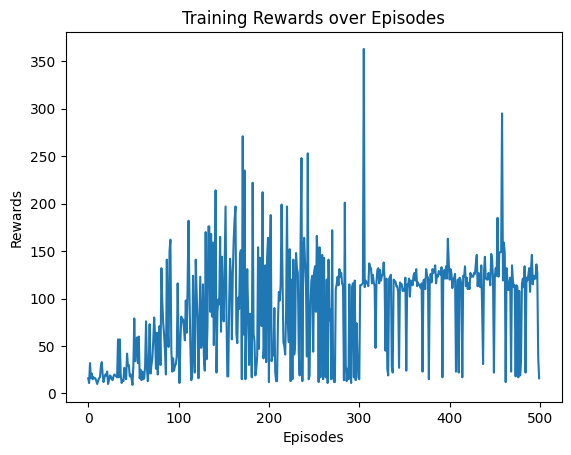

In [14]:
env = gym.make('CartPole-v1')
agent = DQLAgent(env)
agent.train(num_episodes=500)  # Train the agent

### Test Trained Agent

In [15]:
agent.test(num_episodes=10)

Episode 1, Total Reward: 124.0
Episode 2, Total Reward: 135.0
Episode 3, Total Reward: 127.0
Episode 4, Total Reward: 137.0
Episode 5, Total Reward: 121.0
Episode 6, Total Reward: 129.0
Episode 7, Total Reward: 120.0
Episode 8, Total Reward: 145.0
Episode 9, Total Reward: 126.0
Episode 10, Total Reward: 127.0


### Save & Load Trained Model

In [16]:
agent.save_model('dql_cartpole.pth')
agent.load_model('dql_cartpole.pth')

C:\Users\Zhao Qixian\AppData\Local\Temp\ipykernel_3260\1123982213.py:194: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.q_network.load_state_dict(torch.load(filename))


### Corectness of Implementation

In [17]:
state = env.reset()

# Check if Gym returns (state, info) or just state
if isinstance(state, tuple):
    state = state[0]  # Gymnasium (state, info)

state = np.array(state, dtype=np.float32).reshape(-1)  # Ensure state is (4,)
action = agent.select_action(state, training=False)
print("State:", state)
print("Action:", action)


State: [-0.0404366   0.00532978 -0.01902518  0.00079347]
Action: 0


## 1.2 Hyperparameter Exploration and Tuning

### Vary Learning Rate


Training with Learning Rate = 0.05
Episode 0/10000, Total Reward: 18.0, Epsilon: 0.10
Episode 10/10000, Total Reward: 43.0, Epsilon: 0.09
Episode 20/10000, Total Reward: 10.0, Epsilon: 0.09
Episode 30/10000, Total Reward: 26.0, Epsilon: 0.09
Episode 40/10000, Total Reward: 50.0, Epsilon: 0.08
Episode 50/10000, Total Reward: 17.0, Epsilon: 0.08
Episode 60/10000, Total Reward: 11.0, Epsilon: 0.07
Episode 70/10000, Total Reward: 98.0, Epsilon: 0.07
Episode 80/10000, Total Reward: 137.0, Epsilon: 0.07
Episode 90/10000, Total Reward: 147.0, Epsilon: 0.06
Episode 100/10000, Total Reward: 90.0, Epsilon: 0.06
Episode 110/10000, Total Reward: 197.0, Epsilon: 0.06
Episode 120/10000, Total Reward: 18.0, Epsilon: 0.05
Episode 130/10000, Total Reward: 97.0, Epsilon: 0.05
Episode 140/10000, Total Reward: 102.0, Epsilon: 0.05
Episode 150/10000, Total Reward: 60.0, Epsilon: 0.05
Episode 160/10000, Total Reward: 99.0, Epsilon: 0.04
Episode 170/10000, Total Reward: 109.0, Epsilon: 0.04


KeyboardInterrupt: 

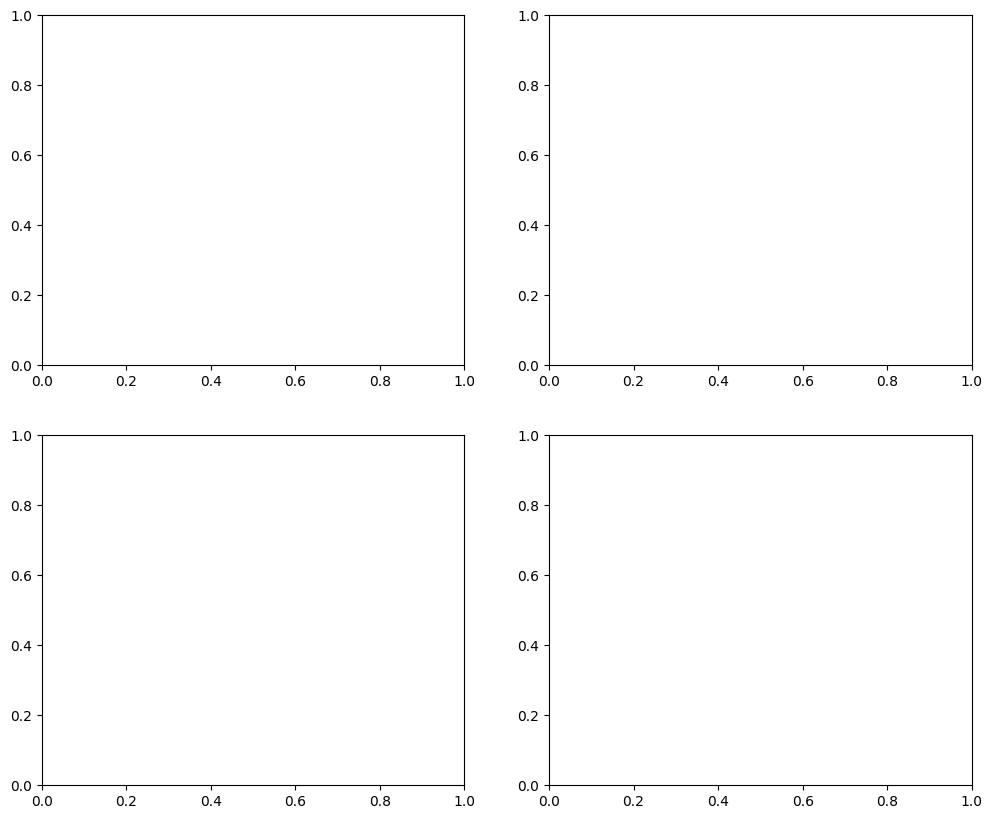

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define learning rates to test
learning_rates = [0.05, 0.1, 0.15, 0.2]

# Create subplots for plotting results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Iterate over different learning rates
for i, lr in enumerate(learning_rates):
    print(f"\nTraining with Learning Rate = {lr}")

    # Initialize a new agent for each LR
    agent = DQLAgent(env, lr=lr, epsilon=0.1)  # Keep epsilon constant at 0.1

    # Train the agent and retrieve reward history
    rewards = agent.train(num_episodes=10000)  # Increase episodes to match reference

    # Compute the moving average for smooth plotting
    window_size = 100
    mean_rewards = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

    # Plot training rewards
    axes[i].plot(mean_rewards)
    axes[i].set_title(f"Mean Rewards vs Episodes (lr={lr}, er=0.10)")
    axes[i].set_xlabel("Episodes")
    axes[i].set_ylabel("Mean Rewards")

plt.tight_layout()
plt.show()


### Vary Initial Exploration Rate

### Choosing the best hyper parameters